#EDA ANALYSIS

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

investor = pd.read_csv("../data/raw/08_investor_transactions.csv")

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [3]:
print(nav.shape)
print(aum.shape)
print(sip.shape)
print(category.shape)
print(folio.shape)
print(investor.shape)
print(holdings.shape)

(46000, 3)
(90, 5)
(48, 6)
(144, 3)
(21, 6)
(32778, 13)
(322, 8)


In [4]:
print(nav.columns)

print(aum.columns)

print(sip.columns)

print(category.columns)

print(folio.columns)

print(investor.columns)

print(holdings.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')
Index(['month', 'category', 'net_inflow_crore'], dtype='str')
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


NAV TREND ANALYSIS CHART

In [5]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [6]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [7]:
nav['date'] = pd.to_datetime(nav['date'])

nav.info()


<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [8]:
nav['amfi_code'].nunique()

40

In [9]:
nav['amfi_code'].unique()[:10]

array([119551, 119552, 119598, 119599, 119120, 100016, 125497, 100033,
       125498, 100025])

In [71]:
fig = px.line(
    nav,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend of 40 Mutual Fund Schemes (2022-2026)',
    height=700
)

# 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    layer="below",
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    layer="below",
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

fig.write_image("../reports/nav_trend_analysis.png")

fig.show()




### Insight

The NAV trends show overall growth across most mutual fund schemes between 2022 and 2026.

The shaded green region highlights the 2023 bull run period, during which many schemes experienced accelerated NAV appreciation.

The red shaded region highlights the 2024 market correction period, where several schemes showed slower growth or temporary declines before recovering.

AUM GROWTH BAR CHART

In [11]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [12]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [13]:
aum['date'] = pd.to_datetime(aum['date'])

aum['year'] = aum['date'].dt.year

aum[['date','year']].head()

,date,year
0,2022-03-31,2022
1,2022-03-31,2022
2,2022-03-31,2022
3,2022-03-31,2022
4,2022-03-31,2022


In [14]:
aum['year'].unique()

array([2022, 2023, 2024, 2025], dtype=int32)

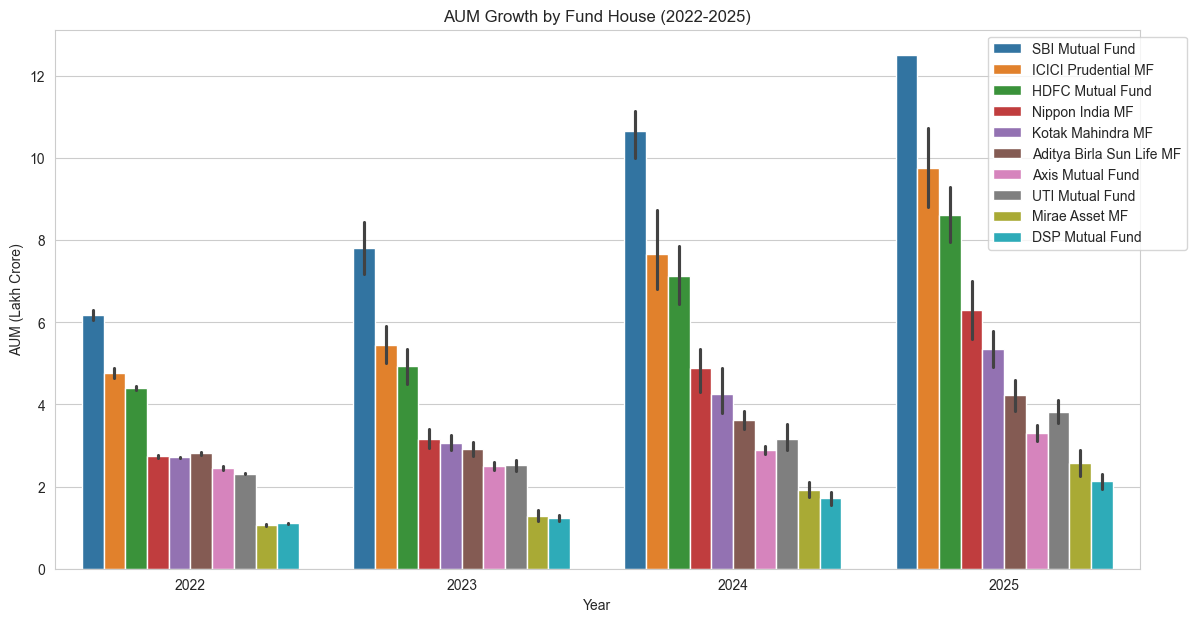

In [72]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title('AUM Growth by Fund House (2022-2025)')
plt.xlabel('Year')
plt.ylabel('AUM (Lakh Crore)')
plt.legend(bbox_to_anchor=(1.05,1))

plt.savefig(
    "../reports/aum_growth_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Insight

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) across the observed period.

Its AUM crossed approximately ₹12.5 lakh crore, demonstrating strong market leadership and investor confidence compared to competing fund houses.

SIP INFLOW TIME - SERIES

In [16]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [17]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [18]:
sip['month'] = pd.to_datetime(sip['month'])

In [19]:
sip.loc[sip['sip_inflow_crore'].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [73]:
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)',
    markers=True
)

fig.add_annotation(
    x='2025-12-01',
    y=31002,
    text='₹31,002 Cr All-Time High (Dec 2025)',
    showarrow=True,
    arrowhead=2,
    ax=-80,
    ay=-40
)


fig.write_image(
    "../reports/sip_inflow_trend.png",
    width=1400,
    height=700
)

plt.show()

### Insight

Monthly SIP inflows increased steadily between January 2022 and December 2025, reflecting growing retail investor participation in mutual funds.

The highest-ever SIP inflow of ₹31,002 crore was recorded in December 2025, highlighting strong investor confidence and continued adoption of systematic investment plans.

CATEGORY INFLOW HEATMAP

In [22]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [23]:
category.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [24]:
category['month'] = pd.to_datetime(category['month'])

In [25]:
pivot_table = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

pivot_table.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


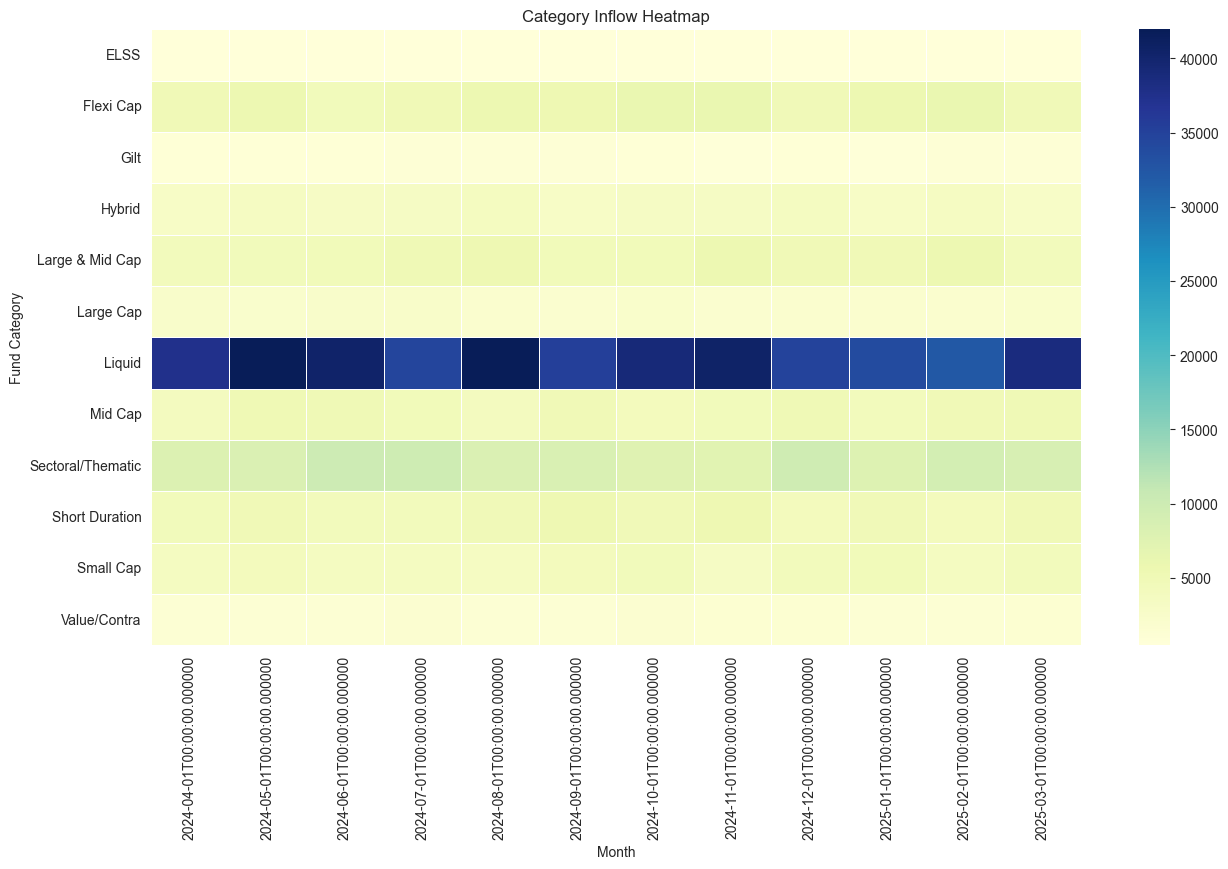

In [74]:
plt.figure(figsize=(15,8))

sns.heatmap(
    pivot_table,
    cmap='YlGnBu',
    linewidths=0.5,
    annot=False
)

plt.title('Category Inflow Heatmap')
plt.xlabel('Month')
plt.ylabel('Fund Category')

plt.savefig(
    "../reports/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The heatmap visualizes net inflows across different mutual fund categories over time.

Darker color intensity indicates stronger investor inflows, while lighter shades represent comparatively lower inflows.

Categories such as Flexi Cap, Mid Cap, and Large & Mid Cap frequently exhibited higher inflows, reflecting sustained investor interest during the analysis period.

INVESTOR DEMOGRAPHIC

In [27]:
investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [28]:
investor.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


In [29]:
age_dist = investor['age_group'].value_counts()

age_dist

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

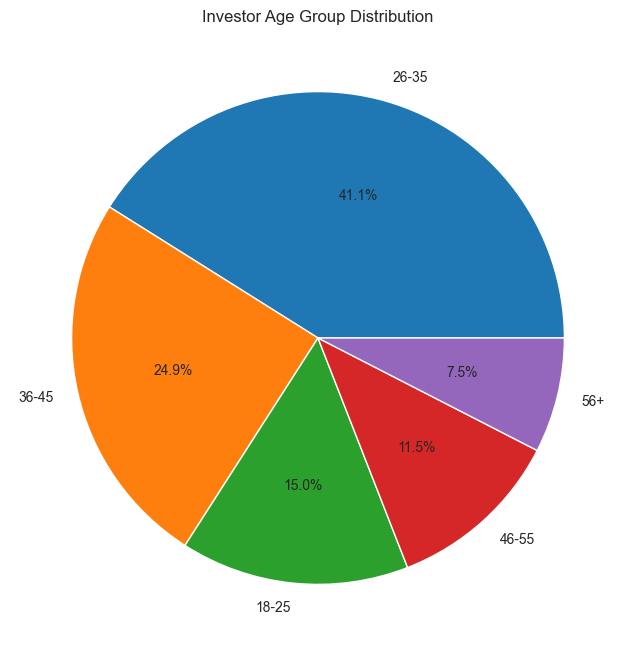

In [75]:
plt.figure(figsize=(8,8))

plt.pie(
    age_dist,
    labels=age_dist.index,
    autopct='%1.1f%%'
)

plt.title('Investor Age Group Distribution')

plt.savefig(
    "../reports/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The age group distribution highlights the dominant investor segments participating in mutual fund investments.

The largest age segment contributes the highest share of investor activity, indicating stronger adoption of mutual funds within that demographic.

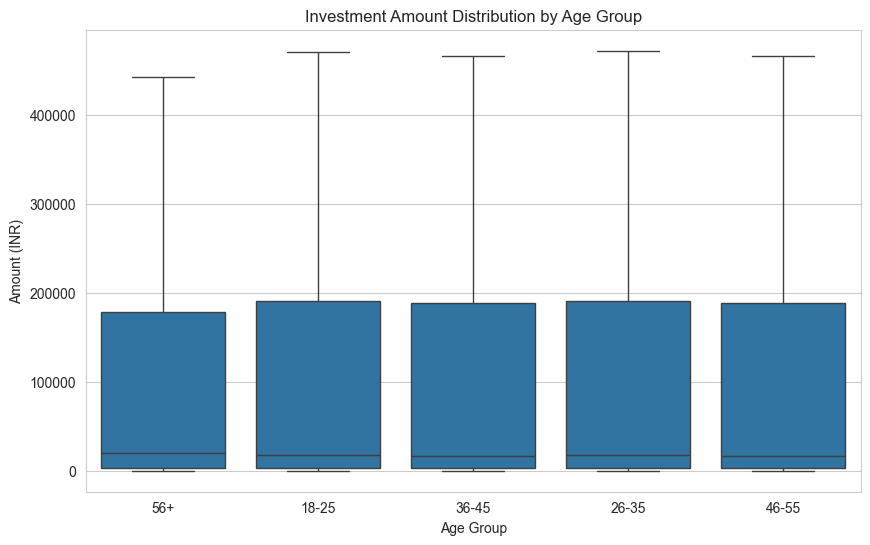

In [76]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x='age_group',
    y='amount_inr',
    showfliers=False
)

plt.title('Investment Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Amount (INR)')

plt.savefig(
    "../reports/investment_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The box plot reveals differences in investment behavior across age groups.

Some age groups exhibit higher median investment amounts and greater variability, indicating stronger participation and larger investments.

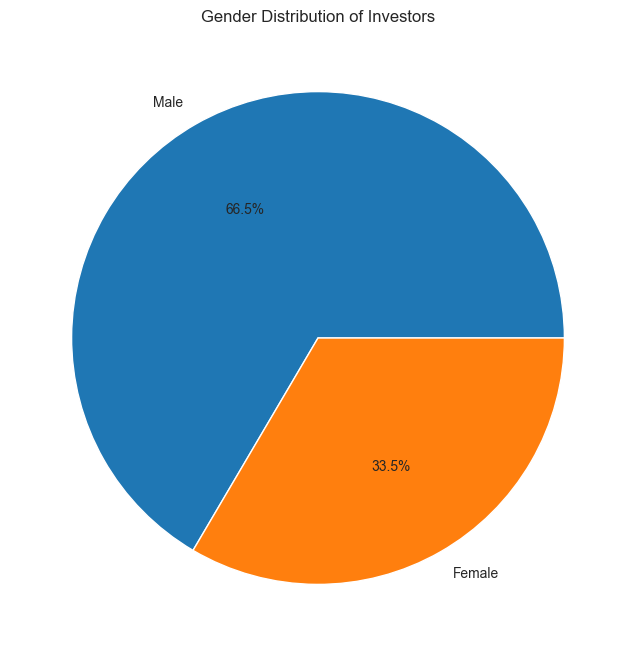

In [77]:
gender_dist = investor['gender'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender_dist,
    labels=gender_dist.index,
    autopct='%1.1f%%'
)

plt.title('Gender Distribution of Investors')

plt.savefig(
    "../reports/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Insight

The gender distribution chart illustrates the participation of male and female investors in mutual fund investments.

The visualization helps identify demographic representation across the investor base.

GEOGRAPHIC DISTRIBUTION

HORIZONTAL BAR CHART

In [34]:
state_amount = (
    investor.groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
)

state_amount.head()

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
Name: amount_inr, dtype: int64

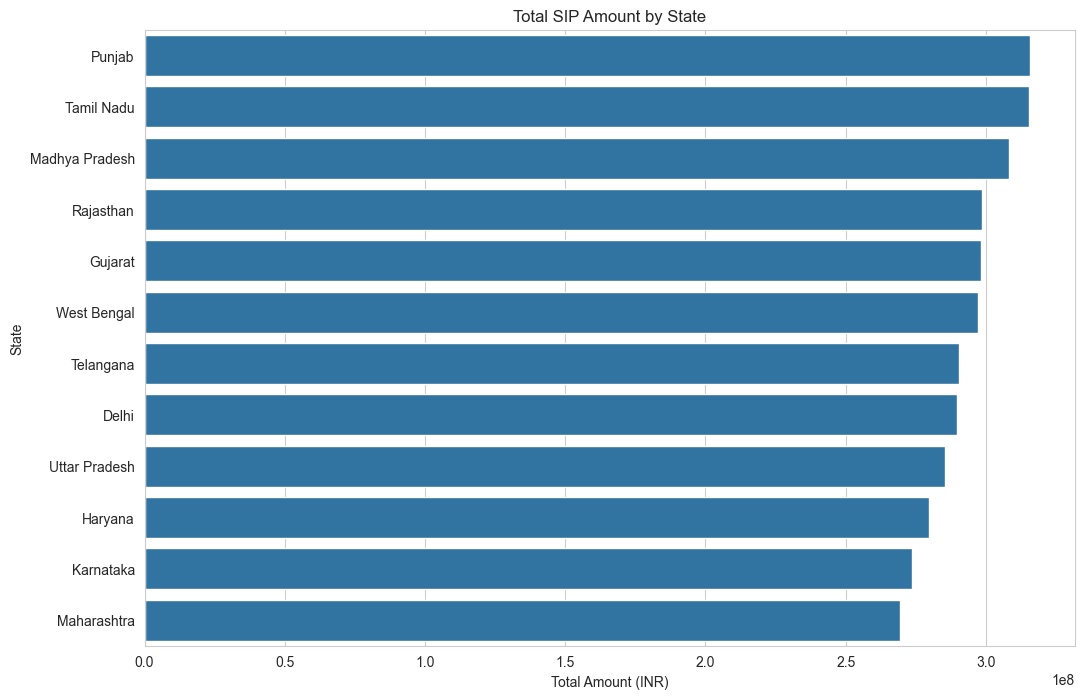

In [78]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=state_amount.values,
    y=state_amount.index
)

plt.title('Total SIP Amount by State')
plt.xlabel('Total Amount (INR)')
plt.ylabel('State')

plt.savefig(
    "../reports/state_sip_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The geographic distribution analysis highlights the contribution of different states to mutual fund investments.

A few states account for a significantly larger share of SIP investments, indicating stronger financial participation and mutual fund adoption in those regions.

T30 VS B30 CITY TIER PIE CHART

In [38]:
city_tier_dist = investor['city_tier'].value_counts()

city_tier_dist

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

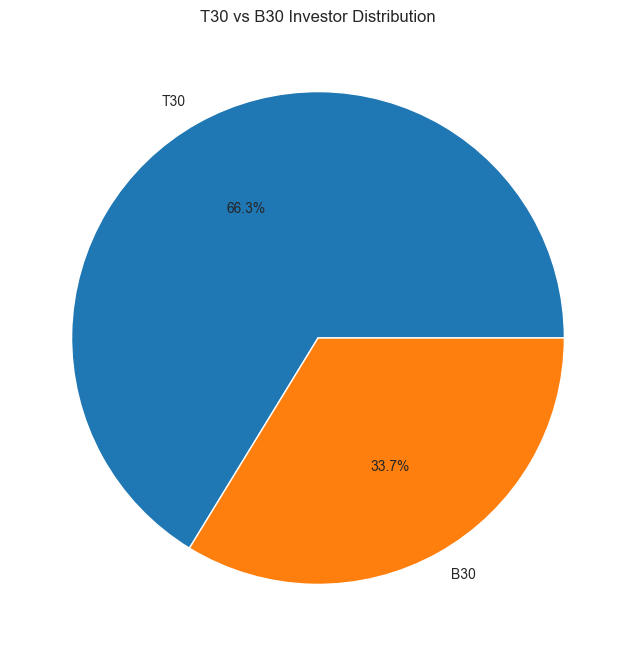

In [79]:
plt.figure(figsize=(8,8))

plt.pie(
    city_tier_dist,
    labels=city_tier_dist.index,
    autopct='%1.1f%%'
)

plt.title('T30 vs B30 Investor Distribution')

plt.savefig(
    "../reports/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The city-tier analysis compares investor participation between Top-30 (T30) cities and Beyond-30 (B30) cities.

A higher share from T30 cities indicates stronger urban penetration, while increasing B30 participation reflects the expanding reach of mutual fund investments across emerging markets.

FOLIO COUNT GROWTH - LINE CHART

In [40]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [41]:
folio.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.1 KB


In [42]:
folio['month'] = pd.to_datetime(folio['month'])

In [81]:
fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    title='Mutual Fund Folio Growth (Jan 2022 - Dec 2025)',
    markers=True
)

fig.show()

fig.write_image("../reports/folio_growth_chart.png")

In [45]:
folio[['month', 'total_folios_crore']].head(1)

,month,total_folios_crore
0,2022-01-01,13.26


In [46]:
folio[['month', 'total_folios_crore']].tail(1)

,month,total_folios_crore
20,2025-12-01,26.12


In [83]:
fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    title='Mutual Fund Folio Growth (Jan 2022 - Dec 2025)',
    markers=True
)

fig.add_annotation(
    x='2022-01-01',
    y=13.26,
    text='13.26 Cr',
    showarrow=True
)

fig.add_annotation(
    x='2025-12-01',
    y=26.12,
    text='26.12 Cr',
    showarrow=True
)

fig.show()

fig.write_image("../reports/folio_growth_chart2.png")


### Insight

The total number of mutual fund folios increased from approximately 13.26 crore in January 2022 to 26.12 crore in December 2025.

The sustained rise in folio count indicates strong growth in retail participation and increasing adoption of mutual fund investments across India.

NAV RETURN CORRELATION MATRIX

In [48]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [49]:
nav_pivot = nav.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,...,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,...,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,...,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,...,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,...,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


In [50]:
selected_funds = nav_pivot.columns[:10]

nav_10 = nav_pivot[selected_funds]

nav_10.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [51]:
daily_returns = nav_10.pct_change()

daily_returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [52]:
corr_matrix = daily_returns.corr()

corr_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


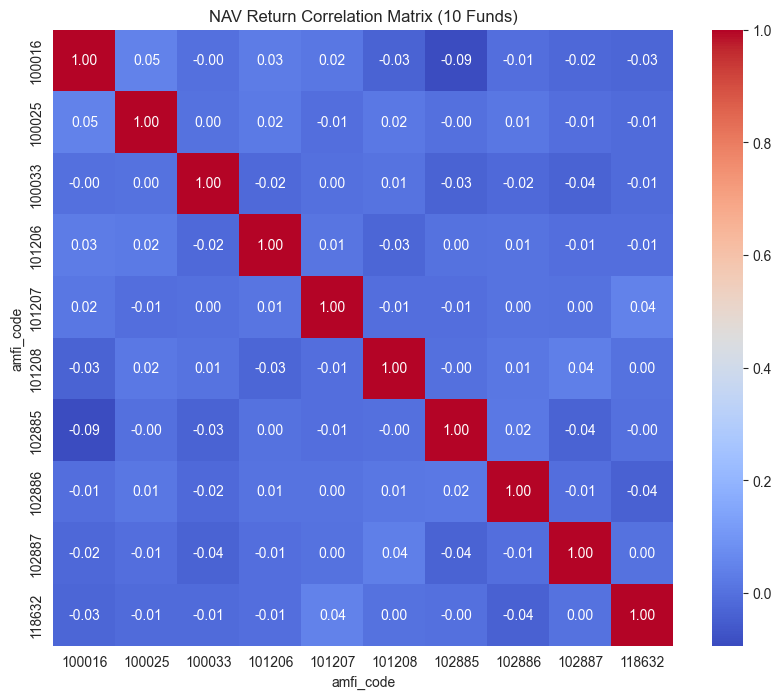

In [84]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('NAV Return Correlation Matrix (10 Funds)')

plt.savefig(
    "../reports/nav_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The correlation matrix measures how similarly different mutual fund NAV returns move over time.

Values close to 1 indicate strong positive correlation, while values closer to 0 indicate weaker relationships.

Several selected funds exhibit high positive correlations, suggesting exposure to similar market movements and investment strategies.

SECTOR ALLOCATION DONUT

In [54]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [55]:
holdings.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB


In [56]:
sector_weights = (
    holdings.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

In [57]:
sector_weights.head(10)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
Name: weight_pct, dtype: float64

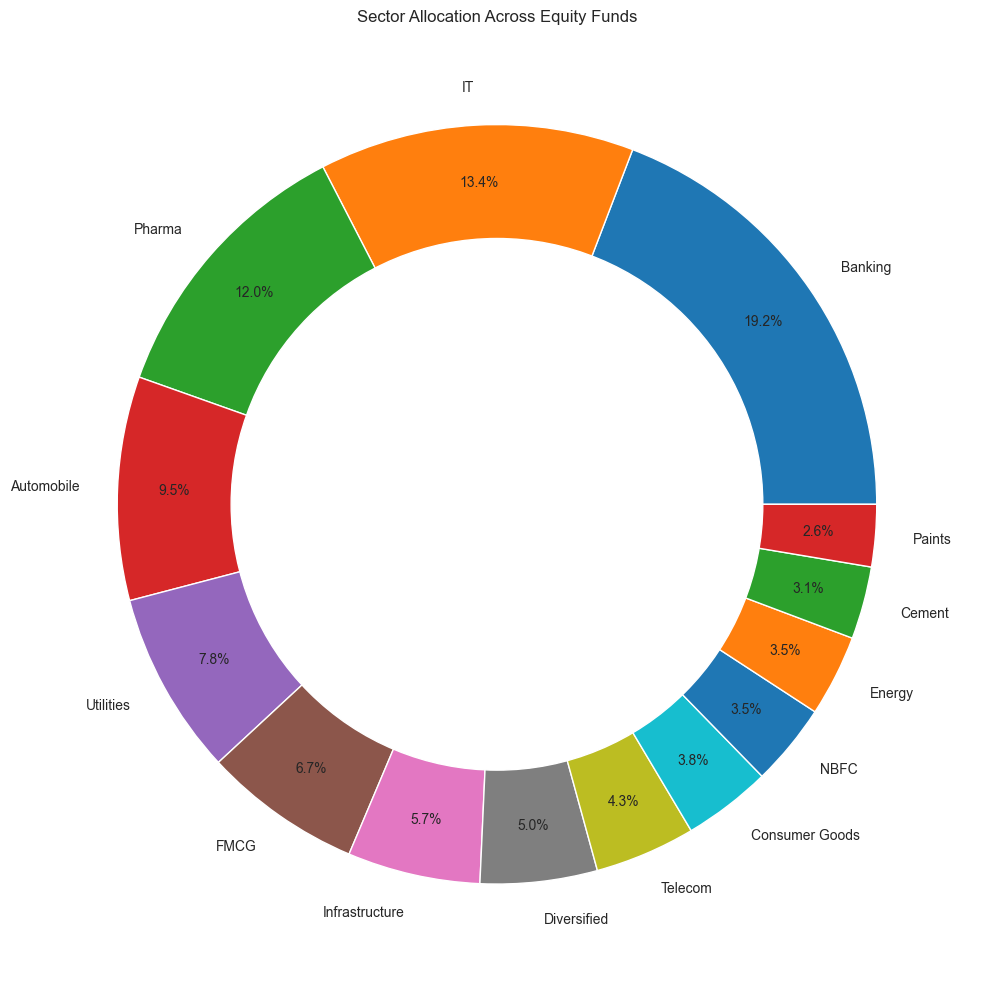

In [85]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%',
    pctdistance=0.85
)

# Create donut hole
centre_circle = plt.Circle((0,0),0.70,fc='white')

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Sector Allocation Across Equity Funds')

plt.tight_layout()

plt.savefig(
    "../reports/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The sector allocation analysis highlights the concentration of portfolio holdings across different sectors.

A significant share of allocations is concentrated in a few dominant sectors, reflecting the investment preferences and strategic positioning of equity mutual funds.

Financials, Technology, and Consumer-oriented sectors generally account for a substantial portion of portfolio exposure.

TOP 10 MUTUAL FUNDS BY LATEST NAV

In [59]:
latest_nav = (
    nav.sort_values('date')
       .groupby('amfi_code')
       .tail(1)
)

latest_nav.head()

,amfi_code,date,nav
22999,118636,2026-05-29,37.8243
43699,149322,2026-05-29,606.2349
18399,118632,2026-05-29,110.5554
17249,120507,2026-05-29,388.5939
16099,120506,2026-05-29,404.4207


In [60]:
top10_nav = (
    latest_nav.sort_values(
        'nav',
        ascending=False
    )
    .head(10)
)

top10_nav

,amfi_code,date,nav
27599,120844,2026-05-29,4268.5497
8049,125497,2026-05-29,1204.9571
33349,101206,2026-05-29,773.2939
43699,149322,2026-05-29,606.2349
6899,100016,2026-05-29,583.6113
24149,120841,2026-05-29,482.1270
14949,120505,2026-05-29,473.7640
35649,101208,2026-05-29,410.1021
16099,120506,2026-05-29,404.4207
17249,120507,2026-05-29,388.5939


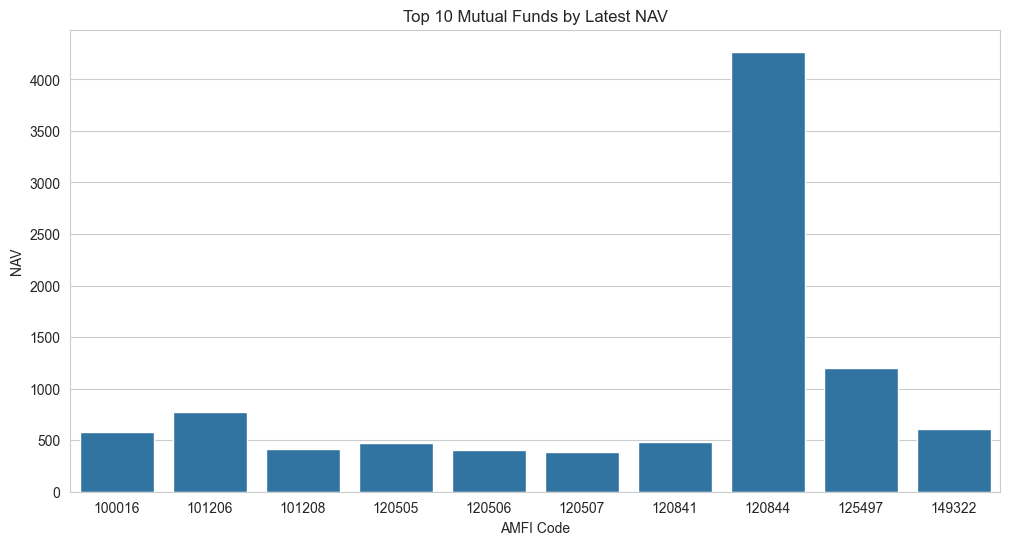

In [61]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_nav,
    x='amfi_code',
    y='nav'
)

plt.title('Top 10 Mutual Funds by Latest NAV')
plt.xlabel('AMFI Code')
plt.ylabel('NAV')

plt.savefig(
    '../reports/top10_nav.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insight

The top-performing mutual fund schemes recorded significantly higher NAV values than their peers.

This indicates stronger long-term appreciation and fund growth over the analysis period.

CATEGORY INFLOW RANKING

In [62]:
category_rank = (
    category.groupby('category')['net_inflow_crore']
    .sum()
    .sort_values(ascending=False)
)

category_rank

category
Liquid               451275.0
Sectoral/Thematic    103829.0
Flexi Cap             63989.0
Large & Mid Cap       57752.0
Short Duration        55530.0
Mid Cap               55312.0
Small Cap             46596.0
Hybrid                38868.0
Large Cap             25633.0
Value/Contra          16980.0
Gilt                  10395.0
ELSS                   6080.0
Name: net_inflow_crore, dtype: float64

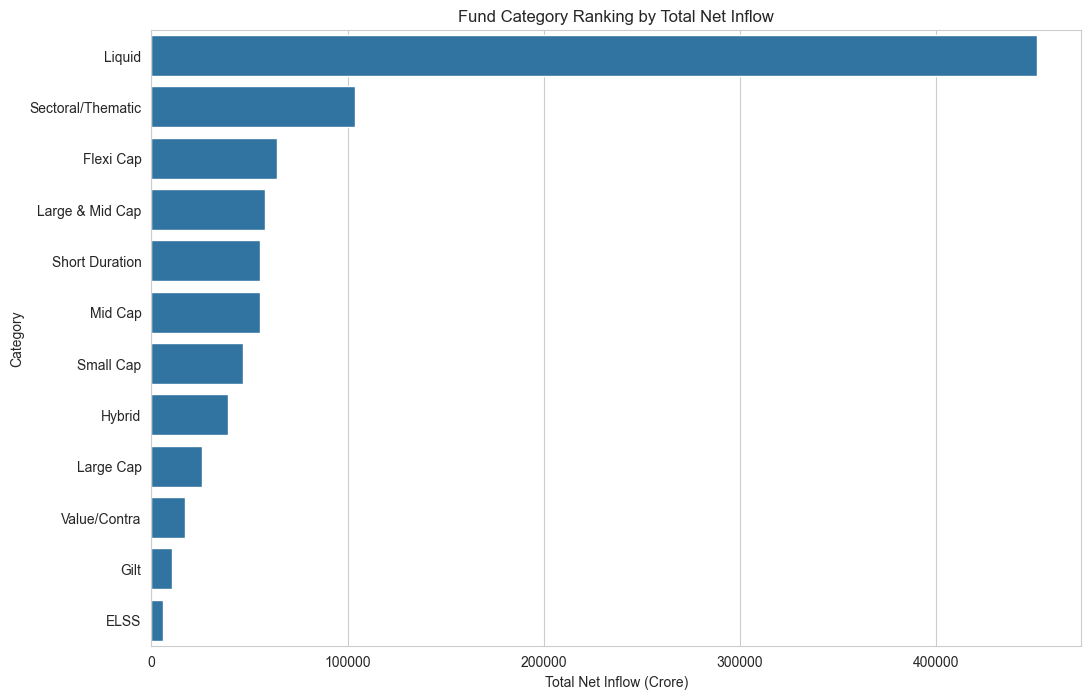

In [63]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=category_rank.values,
    y=category_rank.index
)

plt.title('Fund Category Ranking by Total Net Inflow')
plt.xlabel('Total Net Inflow (Crore)')
plt.ylabel('Category')

plt.savefig(
    '../reports/category_inflow_ranking.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insight

Certain mutual fund categories consistently attracted higher net inflows compared to others.

Investor preference remained concentrated in a limited number of fund categories throughout the period.

EQUTIY VS DEBT VS HYBRID FOLIO TREND

In [64]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [65]:
folio.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   month                21 non-null     datetime64[us]
 1   total_folios_crore   21 non-null     float64       
 2   equity_folios_crore  21 non-null     float64       
 3   debt_folios_crore    21 non-null     float64       
 4   hybrid_folios_crore  21 non-null     float64       
 5   others_folios_crore  21 non-null     float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 1.1 KB


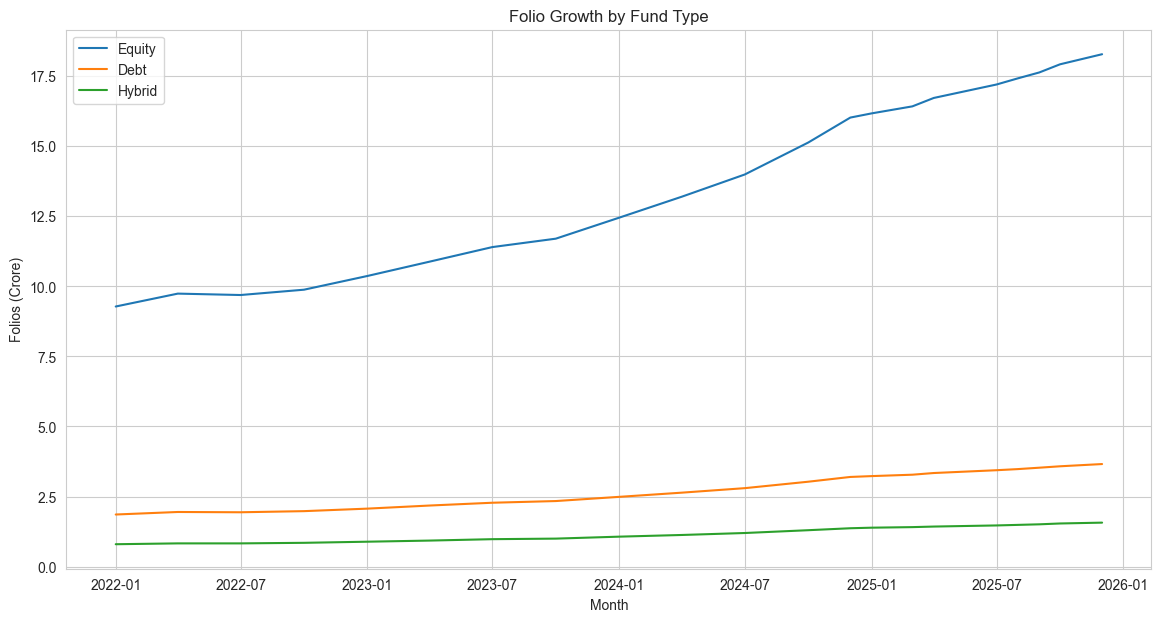

In [66]:
plt.figure(figsize=(14,7))

plt.plot(
    folio['month'],
    folio['equity_folios_crore'],
    label='Equity'
)

plt.plot(
    folio['month'],
    folio['debt_folios_crore'],
    label='Debt'
)

plt.plot(
    folio['month'],
    folio['hybrid_folios_crore'],
    label='Hybrid'
)

plt.title('Folio Growth by Fund Type')
plt.xlabel('Month')
plt.ylabel('Folios (Crore)')

plt.legend()

plt.savefig(
    '../reports/folio_growth_by_type.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insight

Equity folios experienced the strongest growth during the analysis period, substantially outpacing debt and hybrid categories.

This trend reflects increasing investor preference for equity-oriented mutual fund products.

ACTIVE SIP ACCOUNTS GROWTH

In [67]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [68]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[us]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 2.4 KB


In [87]:
fig = px.line(
    sip,
    x='month',
    y='active_sip_accounts_crore',
    markers=True,
    title='Growth in Active SIP Accounts'
)

fig.show()

fig.write_image(
    '../reports/active_sip_accounts_growth.png'
)

### Insight

The number of active SIP accounts increased steadily throughout the analysis period.

The growth reflects rising retail participation and growing adoption of disciplined long-term investing through SIPs.

# Key EDA Findings

### Finding 1

The NAV values of all 40 mutual fund schemes showed an overall upward trend between 2022 and 2025, indicating positive long-term growth. *(Reference: Chart 1 – NAV Trend Analysis)*

### Finding 2

SBI Mutual Fund maintained the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore and demonstrating strong market leadership. *(Reference: Chart 2 – AUM Growth by Fund House)*

### Finding 3

Monthly SIP inflows steadily increased over the analysis period, reaching an all-time high of ₹31,002 crore in December 2025. *(Reference: Chart 3 – SIP Inflow Trend)*

### Finding 4

Several equity-oriented categories consistently attracted stronger net inflows compared to other fund categories. *(Reference: Chart 4 – Category Inflow Heatmap)*

### Finding 5

Investors aged 26–35 years represented the largest share of the investor base, accounting for over 40% of total investors. *(Reference: Chart 5 – Age Group Distribution)*

### Finding 6

Investment amounts varied across age groups, with certain segments showing higher median investment values and wider investment ranges. *(Reference: Chart 6 – Investment Amount Box Plot)*

### Finding 7

Male investors accounted for approximately two-thirds of the investor population, indicating higher participation compared to female investors. *(Reference: Chart 7 – Gender Distribution)*

### Finding 8

A small number of states contributed a disproportionately large share of total SIP investments, reflecting regional concentration in mutual fund adoption. *(Reference: Chart 8 – State-wise SIP Distribution)*

### Finding 9

Total mutual fund folios nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, highlighting strong retail participation growth. *(Reference: Chart 10 – Folio Growth Trend)*

### Finding 10

The correlation matrix revealed strong positive relationships among several selected mutual funds, suggesting exposure to similar market movements and investment strategies. *(Reference: Chart 11 – NAV Correlation Heatmap)*
